# DATA WRANGLING NHL PROJECT
## BAIS:3250 Data Wrangling
### Jacob Johnsen, Lucas Durflinger, Landon Doering
#### 05/01/2026
---

## File Library
---

- `whole_season_games.csv`
- `regular_season_games.csv`
- `playoff_games.csv`
  

<br>

## Import Library
---

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


<br>

## Import Files From BAIS3250_Project_Cleaning
---

In [3]:
#read in each file
whole_season_df = pd.read_csv("whole_season_games.csv", encoding = 'utf-8', sep = ',')
regular_season_df = pd.read_csv("regular_season_games.csv", encoding = 'utf-8', sep = ',')
playoff_df = pd.read_csv("playoff_games.csv", encoding = 'utf-8', sep = ',')


# Question #1: 
---
- Which team statistics are most strongly correlated with winning a game?


In [4]:
#create home dataframe
home_df = whole_season_df[[
    'game_id', 'season',
    'home_teamName', 'home_won', 'home_goals', 'home_shots',
    'home_hits', 'home_pim', 'home_powerPlayOpportunities',
    'home_powerPlayGoals', 'home_faceOffWinPercentage',
    'home_giveaways', 'home_takeaways', 'home_blocked'
]].copy()

#rename columns
home_df.columns = [
    'game_id', 'season', 'team', 'won', 'goals', 'shots',
    'hits', 'pim', 'pp_opportunities', 'pp_goals',
    'faceoff_pct', 'giveaways', 'takeaways', 'blocked'
]

#create away dataframe
away_df = whole_season_df[[
    'game_id', 'season',
    'away_teamName', 'away_won', 'away_goals', 'away_shots',
    'away_hits', 'away_pim', 'away_powerPlayOpportunities',
    'away_powerPlayGoals', 'away_faceOffWinPercentage',
    'away_giveaways', 'away_takeaways', 'away_blocked'
]].copy()

#rename columns 
away_df.columns = [
    'game_id', 'season', 'team', 'won', 'goals', 'shots',
    'hits', 'pim', 'pp_opportunities', 'pp_goals',
    'faceoff_pct', 'giveaways', 'takeaways', 'blocked'
]

#combine each dataframe into one
team_df = pd.concat([home_df, away_df], ignore_index=True)

#sort so each team is next to its opponent involved in the game (easier to read)
team_df = team_df.sort_values(by = ["game_id"]).reset_index(drop = True)

#display
display(team_df)


,game_id,season,team,won,goals,shots,hits,pim,pp_opportunities,pp_goals,faceoff_pct,giveaways,takeaways,blocked
0,2015020001,20152016,Maple Leafs,False,1.0,37.0,26.0,4.0,3.0,1.0,53.1,4.0,7.0,9.0
1,2015020001,20152016,Canadiens,True,3.0,29.0,26.0,8.0,1.0,0.0,46.9,9.0,6.0,15.0
2,2015020002,20152016,Blackhawks,False,2.0,34.0,25.0,2.0,1.0,0.0,52.6,11.0,3.0,3.0
3,2015020002,20152016,Rangers,True,3.0,27.0,43.0,4.0,0.0,0.0,47.4,13.0,10.0,15.0
4,2015020003,20152016,Flames,False,1.0,30.0,28.0,38.0,2.0,0.0,52.2,4.0,11.0,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7981,2017030413,20172018,Capitals,True,3.0,26.0,38.0,4.0,4.0,0.0,62.9,21.0,12.0,26.0
7982,2017030414,20172018,Golden Knights,False,2.0,30.0,39.0,32.0,4.0,0.0,51.6,7.0,8.0,8.0
7983,2017030414,20172018,Capitals,True,6.0,23.0,29.0,20.0,5.0,3.0,48.4,18.0,18.0,24.0
7984,2017030415,20172018,Golden Knights,False,3.0,31.0,39.0,12.0,2.0,1.0,52.5,15.0,22.0,11.0


In [5]:
#set X and y
X = team_df[['goals', 'shots', 'hits', 'pim', 'pp_opportunities', 'pp_goals',
             'faceoff_pct', 'giveaways', 'takeaways', 'blocked']]

y = team_df['won'].astype(int)

#set up train and test 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
log = LogisticRegression(max_iter=1000)

#fit the model
log.fit(X_train, y_train)

#find accuracy
accuracy = log.score(X_test, y_test)
print(f"Accuracy: {accuracy:.5f}")

#interpret coefficients
coef = pd.DataFrame({'feature': X.columns,'coefficient': log.coef_[0]}).sort_values(by='coefficient', ascending=False)

print(f"\nCoefficients:\n")
display(coef)


Accuracy: 0.79036

Coefficients:



,feature,coefficient
0,goals,1.239906
9,blocked,0.082522
8,takeaways,0.047417
4,pp_opportunities,0.025356
6,faceoff_pct,0.006537
2,hits,-0.009865
3,pim,-0.026839
7,giveaways,-0.027644
1,shots,-0.032190
5,pp_goals,-0.212071


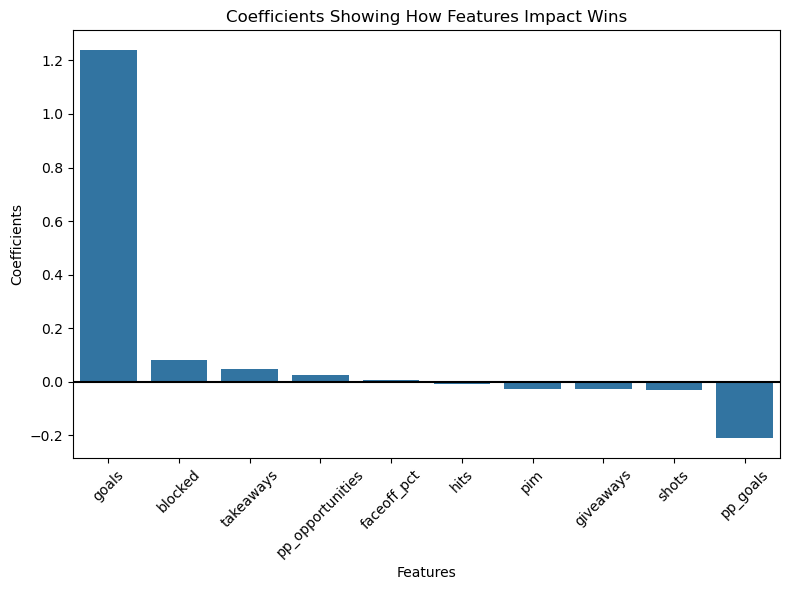

In [6]:
#plot
plt.figure(figsize=(8, 6))
sns.barplot(data=coef, x="feature", y="coefficient")

#title and labels
plt.title("Coefficients Showing How Features Impact Wins")
plt.xlabel("Features")
plt.ylabel("Coefficients")
plt.axhline(0, color='black')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## We are curious to see if removing Goals will increase accuracy of our model.
---

Accuracy: 0.64456

Coefficients:



,feature,coefficient
4,pp_goals,0.694205
8,blocked,0.092090
7,takeaways,0.064580
5,faceoff_pct,0.005151
0,shots,-0.000140
2,pim,-0.010856
6,giveaways,-0.023826
1,hits,-0.024256
3,pp_opportunities,-0.083637


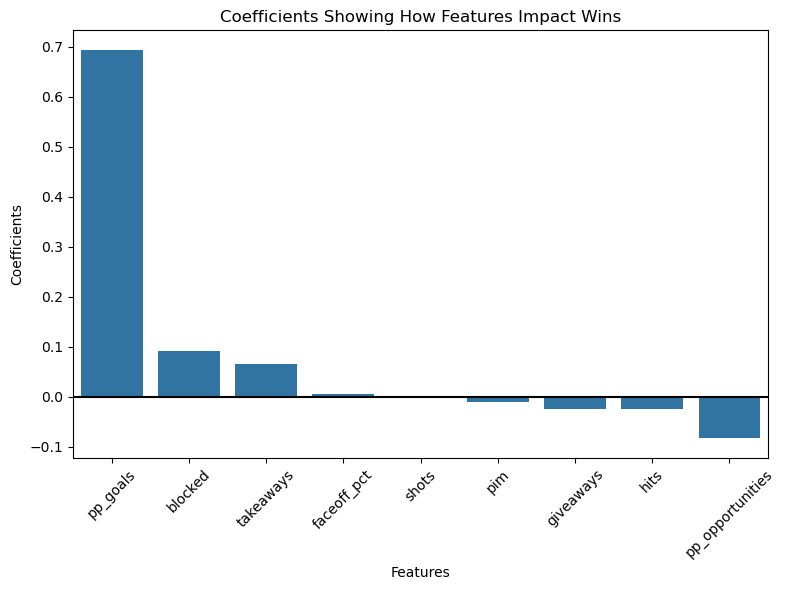

In [14]:
#set X and y
X = team_df[['shots', 'hits', 'pim', 'pp_opportunities', 'pp_goals',
             'faceoff_pct', 'giveaways', 'takeaways', 'blocked']]

y = team_df['won'].astype(int)

#set up train and test 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
log2 = LogisticRegression(max_iter=1000)

#fit the model
log2.fit(X_train, y_train)

#find accuracy
accuracy = log2.score(X_test, y_test)
print(f"Accuracy: {accuracy:.5f}")

#interpret coefficients
coef2 = pd.DataFrame({'feature': X.columns,'coefficient': log2.coef_[0]}).sort_values(by='coefficient', ascending=False)

print(f"\nCoefficients:\n")
display(coef2)

#plot
plt.figure(figsize=(8, 6))
sns.barplot(data=coef2, x="feature", y="coefficient")

#title and labels
plt.title("Coefficients Showing How Features Impact Wins")
plt.xlabel("Features")
plt.ylabel("Coefficients")
plt.axhline(0, color='black')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


<br>

# Question #2: 
---
- Do offensive statistics (such as goals and shots) have a greater impact on winning than defensive statistics (such as blocks and
  takeaways)?


Offensive strength: 0.25933
Defensive strength: 0.06031



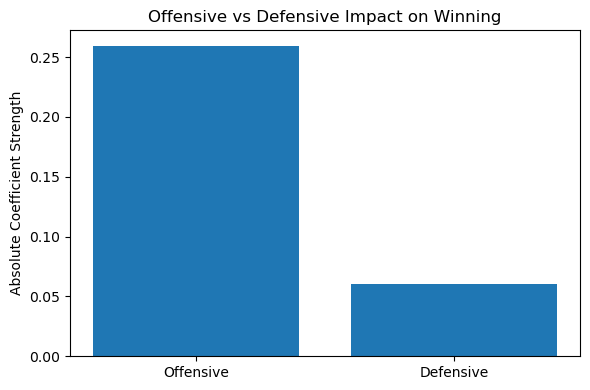

In [8]:
#fit the model from question #1 and create series
log.fit(X_train, y_train)
coef2 = pd.Series(log2.coef_[0], index=X.columns)

#split columns for offensive and defensive stats (goals throws off the model's predictive ability so it is removed)
offensive_stats = ['shots', 'pp_goals', 'pp_opportunities']
defensive_stats = ['blocked', 'takeaways', 'hits']

#absolute their coefficients to find pure impact on a game
offensive_strength = coef2[offensive_stats].abs().mean()
defensive_strength = coef2[defensive_stats].abs().mean()

print(f"Offensive strength: {offensive_strength:.5f}")
print(f"Defensive strength: {defensive_strength:.5f}\n")

#set feature and value for labeling 
feature = ['Offensive', 'Defensive']
value = [offensive_strength, defensive_strength]

#plot
plt.figure(figsize=(6,4))
plt.bar(feature, value)

#title and label
plt.title("Offensive vs Defensive Impact on Winning")
plt.ylabel("Absolute Coefficient Strength")
plt.tight_layout()
plt.show()


<br>

# Question 3: 
---
- Is there a relationship between possession-related statistics (like faceoff win percentage) and winning?

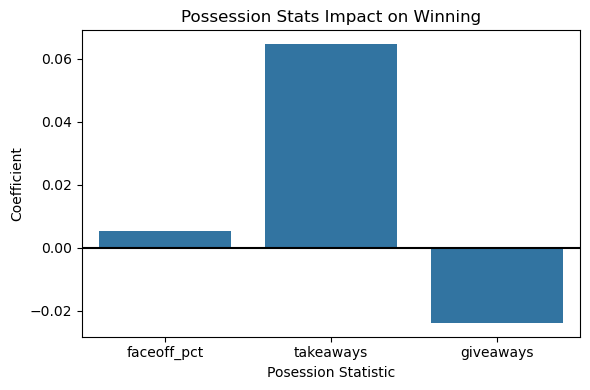

In [9]:
#get posession related stats
possession_stats = ['faceoff_pct', 'takeaways', 'giveaways']

#get the mean of posession stats and group by wins
team_df.groupby('won')[possession_stats].mean()

#find correlation and sort 
team_df[possession_stats + ['won']].corr()['won'].sort_values(ascending=False)

#get coefficients
coef2[possession_stats]

#reset index and give pos_coef columns
pos_coef = coef2[possession_stats].reset_index()
pos_coef.columns = ['stat', 'coefficient']

#plot
plt.figure(figsize=(6,4))
sns.barplot(data=pos_coef, x='stat', y='coefficient')

#title 
plt.axhline(0, color='black')
plt.title("Possession Stats Impact on Winning")
plt.xlabel("Posession Statistic")
plt.ylabel("Coefficient")
plt.tight_layout()
plt.show()


<br>

# Question #4:
---
- Do team statistics increase or decrease between regular season and post season games?
  

In [10]:
#convert regular season
#convert from game level to team level regular season for home team
reg_home = regular_season_df[[
    'home_goals','home_shots','home_hits','home_pim',
    'home_powerPlayOpportunities','home_powerPlayGoals',
    'home_faceOffWinPercentage','home_giveaways',
    'home_takeaways','home_blocked'
]].copy()

#rename columns
reg_home.columns = [
    'goals','shots','hits','pim','pp_opportunities','pp_goals',
    'faceoff_pct','giveaways','takeaways','blocked'
]

#convert from game level to team level regular season for away teams
reg_away = regular_season_df[[
    'away_goals','away_shots','away_hits','away_pim',
    'away_powerPlayOpportunities','away_powerPlayGoals',
    'away_faceOffWinPercentage','away_giveaways',
    'away_takeaways','away_blocked'
]].copy()

#rename columns
reg_away.columns = [
    'goals','shots','hits','pim','pp_opportunities','pp_goals',
    'faceoff_pct','giveaways','takeaways','blocked'
]

#combine them into single dataframe
regular_season_team = pd.concat([reg_home, reg_away], ignore_index=True)


In [11]:
#convert post season
#convert from game level to team level post season for home team
post_home = playoff_df[[
    'home_goals','home_shots','home_hits','home_pim',
    'home_powerPlayOpportunities','home_powerPlayGoals',
    'home_faceOffWinPercentage','home_giveaways',
    'home_takeaways','home_blocked'
]].copy()

#rename columns
post_home.columns = [
    'goals','shots','hits','pim','pp_opportunities','pp_goals',
    'faceoff_pct','giveaways','takeaways','blocked'
]

#convert from game level to team level post season for away teams
post_away = playoff_df[[
    'away_goals','away_shots','away_hits','away_pim',
    'away_powerPlayOpportunities','away_powerPlayGoals',
    'away_faceOffWinPercentage','away_giveaways',
    'away_takeaways','away_blocked'
]].copy()

#rename columns
post_away.columns = [
    'goals','shots','hits','pim','pp_opportunities','pp_goals',
    'faceoff_pct','giveaways','takeaways','blocked'
]

#combine them into single dataframe
post_season_team = pd.concat([post_home, post_away], ignore_index=True)


In [12]:
#compare averages
reg_means = regular_season_team.mean()
post_means = post_season_team.mean()

#create comparison dataframe
comparison_df = pd.DataFrame({
    'Regular Season': reg_means,
    'Playoffs': post_means
})

#compare columns
comparison_df['Difference'] = comparison_df['Playoffs'] - comparison_df['Regular Season']

#display
display(comparison_df)

,Regular Season,Playoffs,Difference
goals,2.776467,2.715649,-0.060819
shots,30.657330,30.868321,0.210990
hits,22.185473,32.950382,10.764909
pim,9.183999,10.765267,1.581268
pp_opportunities,3.047440,3.211832,0.164392
pp_goals,0.588850,0.631679,0.042829
faceoff_pct,50.000000,50.000000,0.000000
giveaways,8.899357,10.333969,1.434613
takeaways,6.780622,7.427481,0.646859
blocked,14.375235,16.761450,2.386216


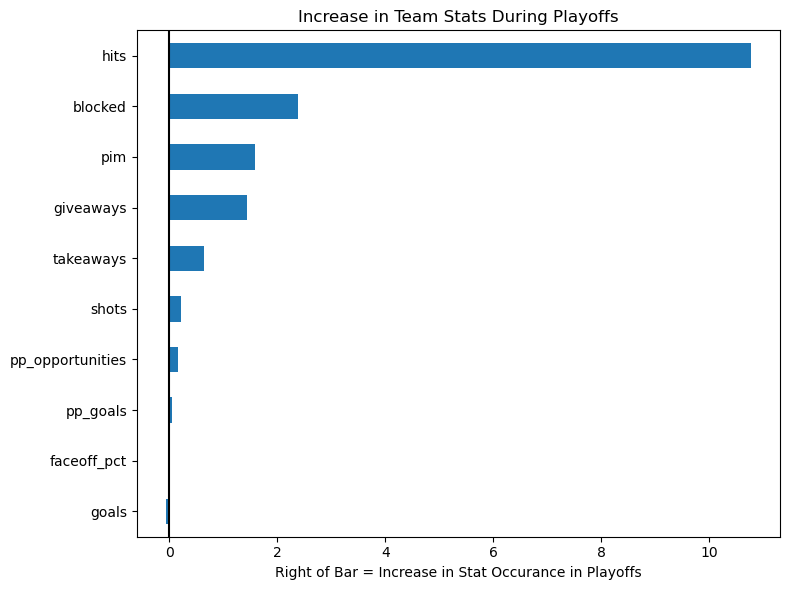

In [13]:
#sort the difference values
diff_sorted = comparison_df['Difference'].sort_values()

#plot
plt.figure(figsize=(8,6))
diff_sorted.plot(kind='barh')

#title
plt.axvline(0, color='black')
plt.title("Increase in Team Stats During Playoffs")
plt.xlabel("Right of Bar = Increase in Stat Occurance in Playoffs")
plt.tight_layout()
plt.show()


<br>